In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from sklearn import cluster


In [2]:
def generate_alternative_data(n, p, sigma, K, mean_range=5):
    X_parts = []
    n_per_cluster = n // K

    cluster_means = np.random.uniform(low=-mean_range, high=mean_range, size=(K, p))

    for i in range(K):
        X_cluster = np.random.normal(loc=cluster_means[i], scale=sigma, size=(n_per_cluster, p))
        X_parts.append(X_cluster)
    
    X = np.vstack(X_parts)
    return X
def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu
def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    #obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    # Extract cluster indices
    left_indices = node.left.points
    right_indices = node.right.points

    # Compute cluster means
    left_mean = np.mean(X[left_indices, :], axis=0)
    right_mean = np.mean(X[right_indices, :], axis=0)

    # Compute the Euclidean distance between cluster means
    obs_target = np.linalg.norm(left_mean - right_mean)

    # Compute the scaling factor
    n_left = len(left_indices)
    n_right = len(right_indices)
    scale_factor = sigma * np.sqrt(1 / n_left + 1 / n_right)
    p_value = 1 - chi.cdf(obs_target/scale_factor, df=p)
    return p_value

In [3]:
def check_power_multi_tau(n, p, sigma, K, tau_list, layer, signal = 5, alpha=0.05, num_trials=300):
    power_results_sel = {}
    power_results_naive = {}

    for tau in tau_list:
        p_values = []
        p_values_n = []
        for _ in range(num_trials):
            #X, y = make_blobs(n_samples=n, n_features=p, centers=K, cluster_std=sigma)
            X = generate_alternative_data(n, p, sigma, K,mean_range=signal)
            model = AgglomerativeClustering(X, tau=tau, n_clusters=K-2, linkage="single")
            model.fit()
                
            winning_nodes = list(model.existing_clusters_log.keys())
            key = winning_nodes[layer]
            node = key[0].parent
    
            p_val, _, _ = model.merge_inference(node, grid_width=20,ncoarse=20, ngrid=1000, sd=sigma)
            naive_val = naive_p_value(X, node)
    
            p_values.append(p_val)
            p_values_n.append(naive_val)

        p_values = np.array(p_values)
        p_values_n = np.array(p_values_n)

        # Power = proportion of rejections
        power_results_sel[tau] = np.mean(p_values < alpha)
        power_results_naive[tau] = np.mean(p_values_n < alpha)

    # Plotting power vs tau
    plt.figure(figsize=(8, 6))
    plt.plot(tau_list, [power_results_sel[tau] for tau in tau_list], marker='o', label="Selective Inference")
    plt.plot(tau_list, [power_results_naive[tau] for tau in tau_list], marker='x', label="Naive Inference")
    plt.axhline(y=1-alpha, linestyle='--', color='red', label=f"Significance level α = {alpha}")
    plt.xlabel("Tau (Randomization Level)")
    plt.ylabel("Empirical Power")
    plt.title(f"Power vs. Tau (layer {layer}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return power_results_sel, power_results_naive

level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level

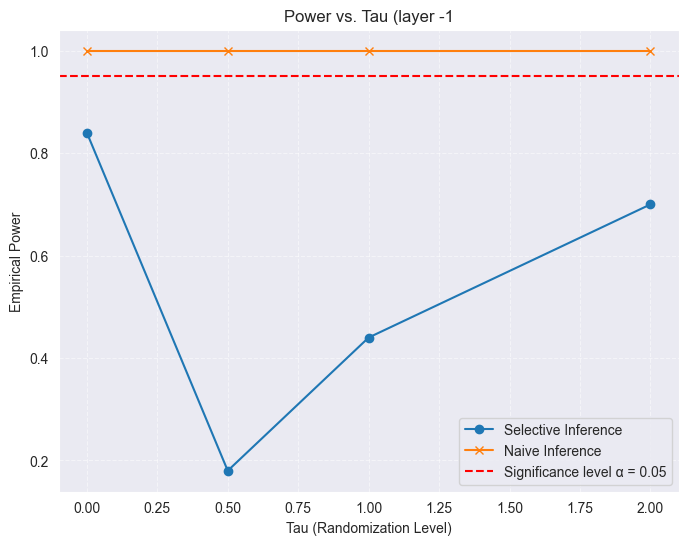

({0: np.float64(0.84),
  0.5: np.float64(0.18),
  1: np.float64(0.44),
  2: np.float64(0.7)},
 {0: np.float64(1.0),
  0.5: np.float64(1.0),
  1: np.float64(1.0),
  2: np.float64(1.0)})

In [6]:
tau_list = [0,0.5,1,2]
check_power_multi_tau(20,15,2,10,tau_list,-1,signal=5,num_trials=100)

level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level

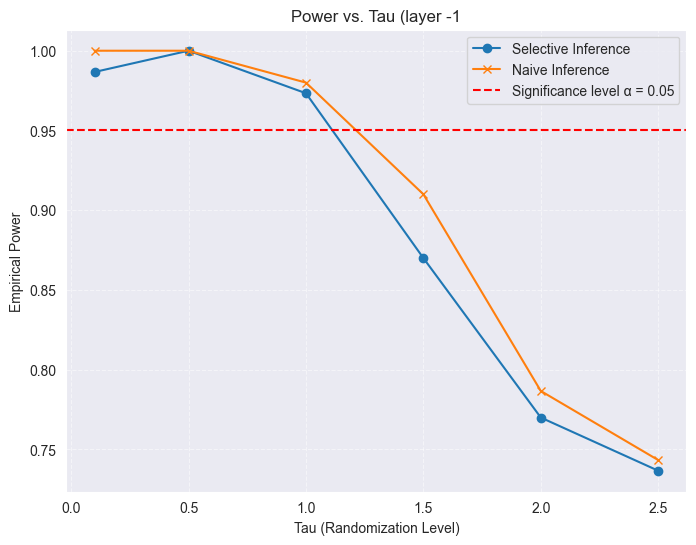

({0.1: np.float64(0.9866666666666667),
  0.5: np.float64(1.0),
  1: np.float64(0.9733333333333334),
  1.5: np.float64(0.87),
  2: np.float64(0.77),
  2.5: np.float64(0.7366666666666667)},
 {0.1: np.float64(1.0),
  0.5: np.float64(1.0),
  1: np.float64(0.98),
  1.5: np.float64(0.91),
  2: np.float64(0.7866666666666666),
  2.5: np.float64(0.7433333333333333)})

In [83]:
tau_list = [0.1,0.5,1,1.5,2,2.5]
check_power_multi_tau(20,15,1,10,tau_list,-1,signal=5)

level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
le

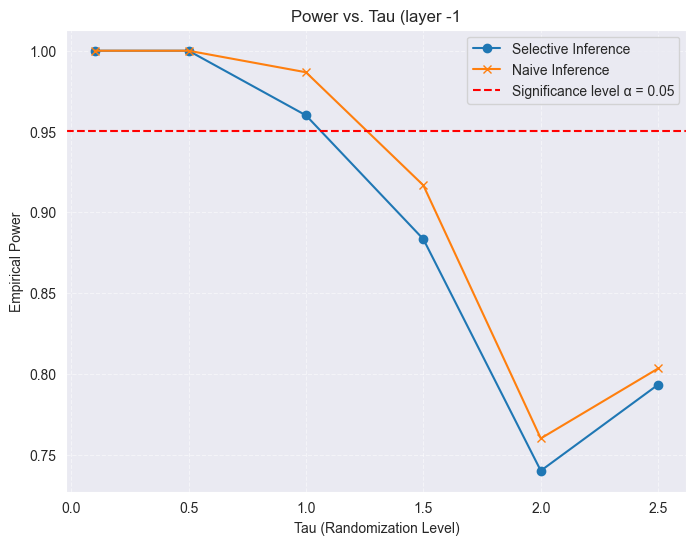

({0.1: np.float64(1.0),
  0.5: np.float64(1.0),
  1: np.float64(0.96),
  1.5: np.float64(0.8833333333333333),
  2: np.float64(0.74),
  2.5: np.float64(0.7933333333333333)},
 {0.1: np.float64(1.0),
  0.5: np.float64(1.0),
  1: np.float64(0.9866666666666667),
  1.5: np.float64(0.9166666666666666),
  2: np.float64(0.76),
  2.5: np.float64(0.8033333333333333)})

In [84]:
tau_list = [0.1,0.5,1,1.5,2,2.5]
check_power_multi_tau(30,15,1,10,tau_list,-1,signal=5)